a)
The first big anomaly in the data is around 06:00 29th october in the Auroral Electrojet data. In the Distrubance Storm Time data, the first big dip is early on the 30th of october, but it starts dropping 06:00 at the 29th as well.
A second storm appears to hit Earth later at the 30th of october and reaches a peak early 31th october.

In [40]:
import numpy as np
import pandas as pd

# Load and explore data, na_values removes bad or missing data
df = pd.read_csv("../data/ACE_MAGSWE_Data.txt", delim_whitespace=True, comment="%", na_values= -9999.9)
print(df.head())
df.describe()

/tmp/ipykernel_6611/2361215610.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("../data/ACE_MAGSWE_Data.txt", delim_whitespace=True, comment="%", na_values= -9999.9)


   2003  276  0  0.1   8.035  4.184  -452.09  54.28  -1.13  9.352  -10.158  \
0  2003  276  0    1  12.058  4.167  -453.39  51.84  -8.75  9.372   -9.990   
1  2003  276  0    2  15.994  4.497  -449.36  63.72 -19.31  9.523   -9.466   
2  2003  276  0    3  20.016  5.028  -455.07  69.84 -27.11  9.474   -9.246   
3  2003  276  0    4  24.038  4.788  -458.96  78.00 -38.82  9.852   -8.479   
4  2003  276  0    5  27.974  4.581  -459.17  67.17 -17.95  9.838   -9.488   

   -1.318  1.4230e+06  1.3286e+05  -1.5612e+05  
0  -2.309   1423000.0    132820.0    -156160.0  
1  -3.524   1423000.0    132770.0    -156200.0  
2  -4.041   1423000.0    132730.0    -156240.0  
3  -4.940   1423000.0    132690.0    -156290.0  
4  -2.789   1423000.0    132650.0    -156330.0  


,2003,276,0,0.1,8.035,4.184,-452.09,54.28,-1.13,9.352,-10.158,-1.318,1.4230e+06,1.3286e+05,-1.5612e+05
count,72899.0,72899.000000,72899.000000,72899.000000,72899.000000,64380.000000,65759.000000,65759.000000,65759.000000,72899.000000,72899.000000,72899.000000,7.289900e+04,72899.000000,72899.000000
mean,2003.0,302.500364,11.493491,29.439210,29.861436,5.073507,-562.403554,-2.113959,-0.693107,0.013004,-0.285957,0.071358,1.477152e+06,168343.465754,-174723.082662
std,0.0,15.585689,6.922468,17.317893,17.315016,4.522111,121.155357,36.079094,27.771125,5.982613,6.217433,6.305421,3.779133e+04,37109.925901,52273.801033
min,2003.0,276.000000,0.000000,0.000000,0.000000,0.170000,-1251.470000,-166.450000,-176.350000,-42.019000,-44.805000,-53.847000,1.423000e+06,73503.000000,-250760.000000
25%,2003.0,289.000000,5.000000,14.000000,14.995000,2.794000,-630.380000,-25.130000,-17.600000,-4.087000,-3.773000,-2.535000,1.441500e+06,141820.000000,-214570.000000
50%,2003.0,303.000000,12.000000,29.000000,30.010000,4.144000,-552.550000,-7.430000,-1.660000,0.656000,-0.644000,0.102000,1.477600e+06,167080.000000,-185580.000000
75%,2003.0,316.000000,17.000000,44.000000,45.014000,5.530000,-478.070000,17.060000,17.010000,4.305500,3.218000,2.798000,1.507600e+06,196040.000000,-142550.000000
max,2003.0,329.000000,23.000000,59.000000,59.990000,78.641000,-291.800000,199.140000,191.780000,27.750000,44.232000,46.626000,1.543400e+06,240630.000000,-33923.000000


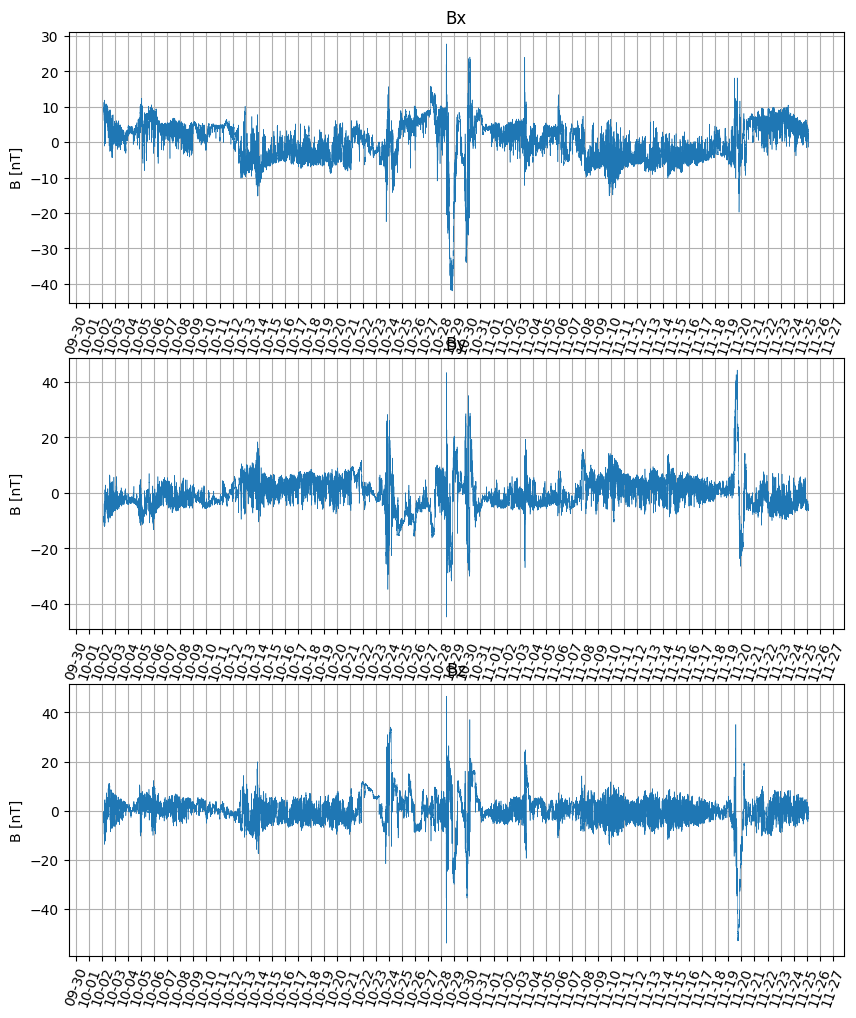

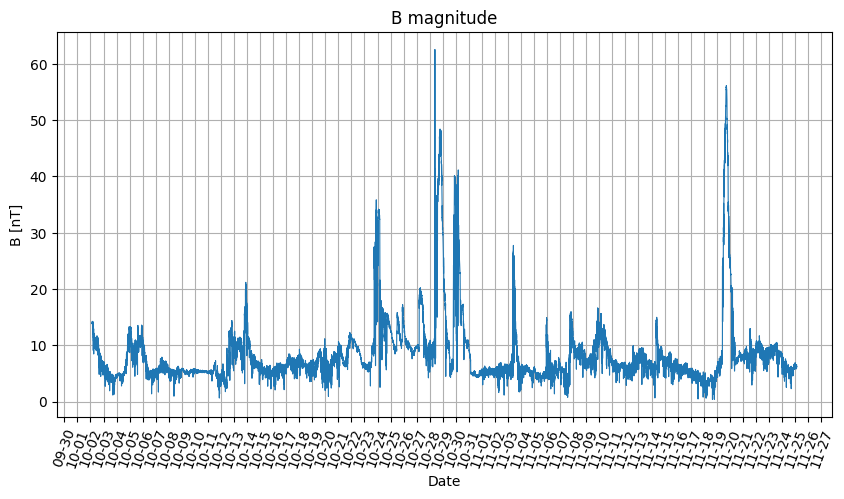

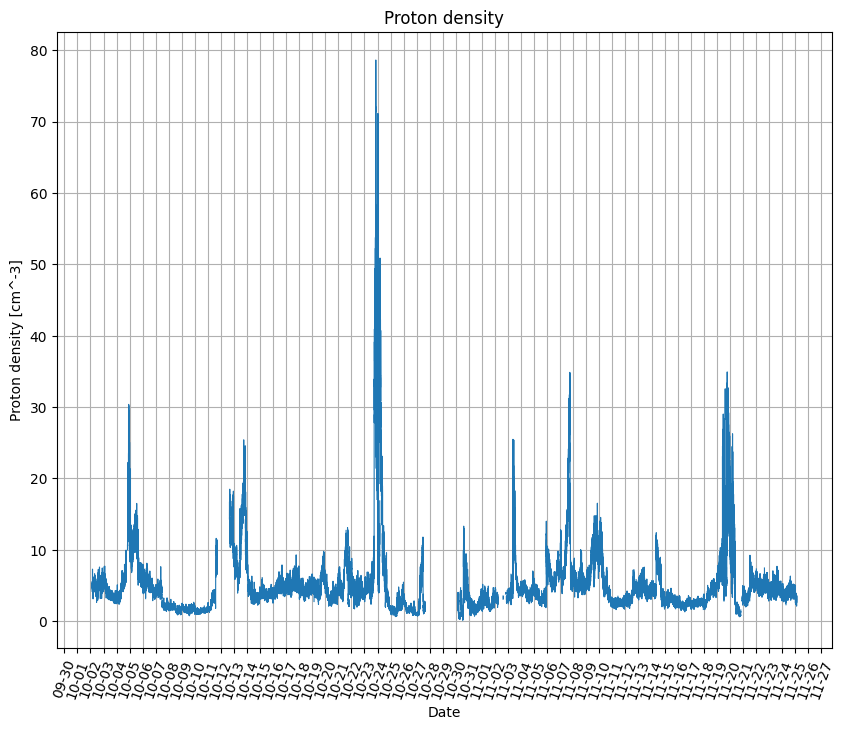

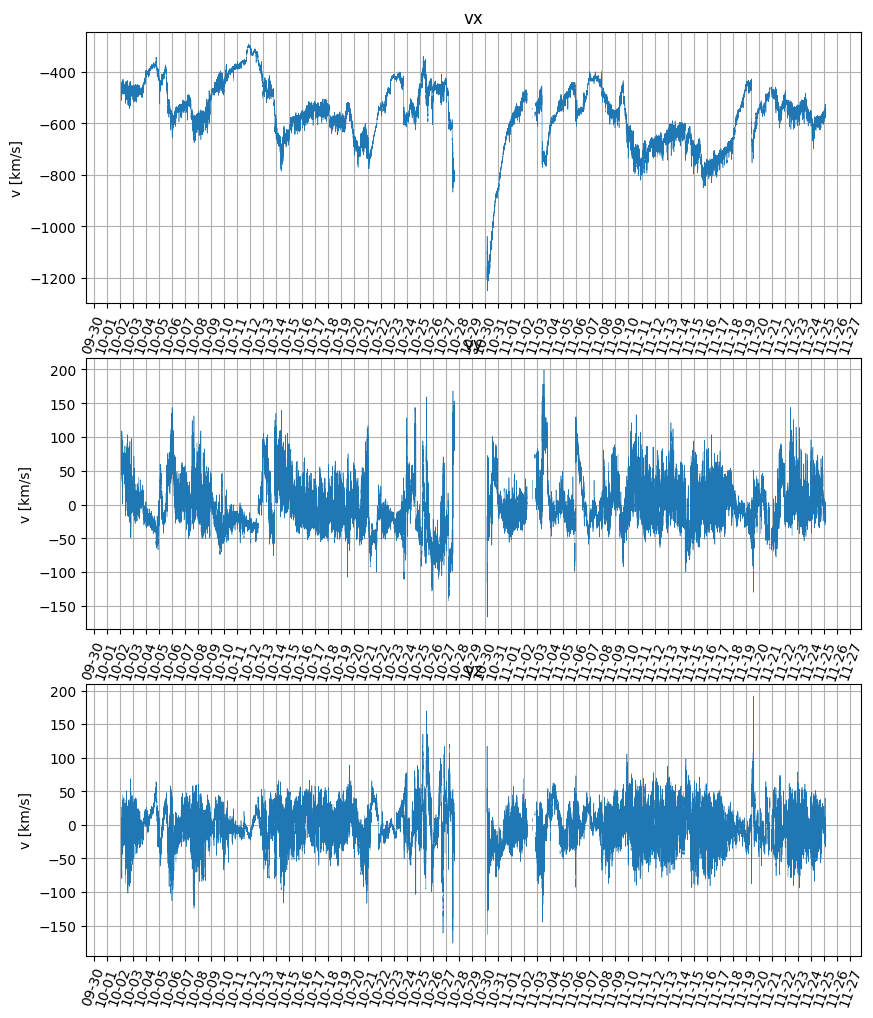

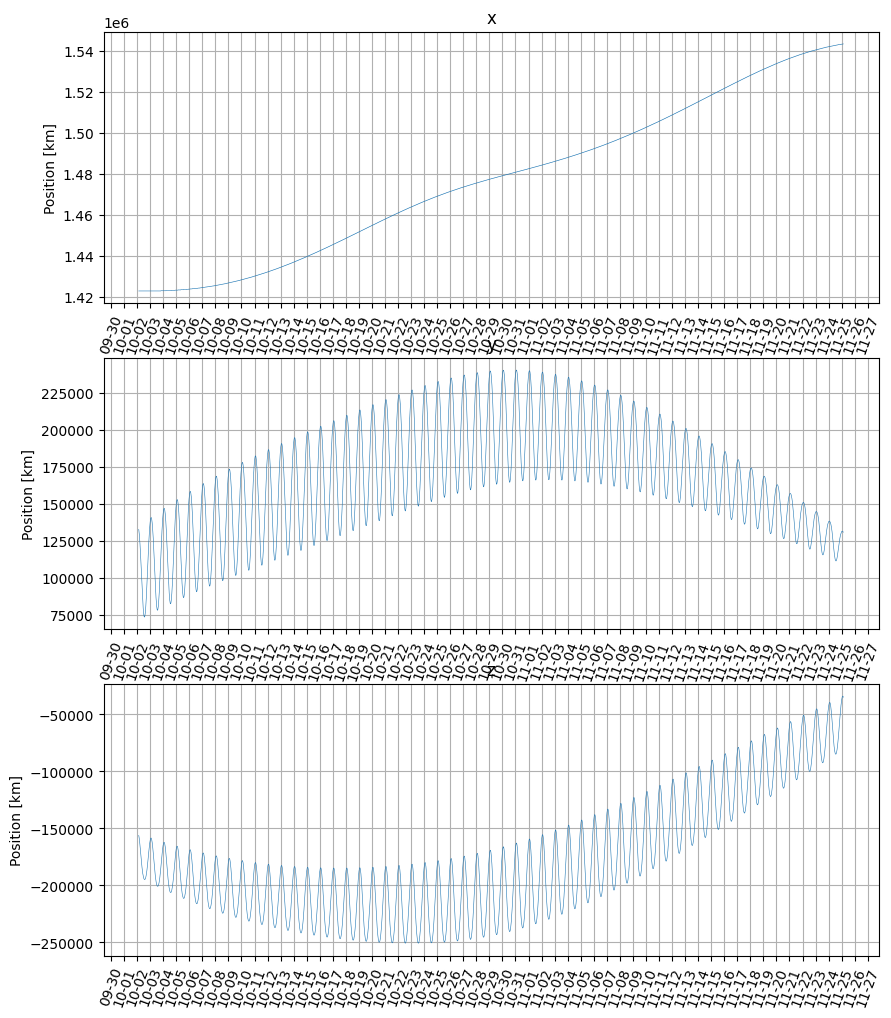

In [49]:
from matplotlib import pyplot as plt
import datetime
import matplotlib.dates as mdates

# crate B matrix

# starts at second row for some reason
B = df.iloc[:,9:12].to_numpy()
Bmag = np.sqrt(B[:,0]**2+B[:,1]**2+B[:,2]**2)
pro_dens = df.iloc[:,5].to_numpy()
pro_vel = df.iloc[:,6:9].to_numpy()
ACE_pos= df.iloc[:,12:15].to_numpy()

Y   = df.iloc[:,0].astype(int)          # year
DOY = df.iloc[:,1].astype(int)          # day-of-year (1..365/366)
H   = df.iloc[:,2].astype(int)
MI  = df.iloc[:,3].astype(int)
S   = df.iloc[:,4].astype(float)        # seconds w/ milliseconds

date = (pd.to_datetime(Y.astype(str), format="%Y")
        + pd.to_timedelta(DOY - 1, unit="D")
        + pd.to_timedelta(H, unit="h")
        + pd.to_timedelta(MI, unit="m")
        + pd.to_timedelta(S, unit="s"))

fig, axs = plt.subplots(3,1,sharex=0, figsize=(10,12))
axs[0].plot(date,B[:,0],lw=0.4,label="Bx")
axs[0].set_title("Bx")
axs[0].set_ylabel("B [nT]")
axs[0].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[0].tick_params(axis='x', rotation=70)

axs[1].plot(date,B[:,1],lw=0.4,label="By")
axs[1].set_title("By")
axs[1].set_ylabel("B [nT]")
axs[1].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[1].tick_params(axis='x', rotation=70)

axs[2].plot(date,B[:,2],lw=0.4,label="Bz")
axs[2].set_title("Bz")
axs[2].set_ylabel("B [nT]")
axs[2].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[2].tick_params(axis='x', rotation=70)

for ax in axs:
    ax.grid(True)


plt.figure(figsize=(10,5))
plt.plot(date,Bmag,lw=0.8)
plt.title("B magnitude")
plt.xticks(rotation=70)
plt.xlabel("Date")
plt.ylabel("B [nT]")
plt.grid(True)
ax = plt.gca()  # get current axis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.show()



plt.figure(figsize=(10,8))
plt.plot(date,pro_dens,lw=0.8)
plt.title("Proton density")
plt.xticks(rotation=70)
plt.xlabel("Date")
plt.ylabel("Proton density [cm^-3]")
ax = plt.gca()  # get current axis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.grid(True)
plt.show()

fig, axs = plt.subplots(3,1,sharex=0, figsize=(10,12))
axs[0].plot(date,pro_vel[:,0],lw=0.4,label="Bx")
axs[0].set_title("vx")
axs[0].set_ylabel("v [km/s]")
axs[0].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[0].tick_params(axis='x', rotation=70)

axs[1].plot(date,pro_vel[:,1],lw=0.4,label="By")
axs[1].set_title("vy")
axs[1].set_ylabel("v [km/s]")
axs[1].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[1].tick_params(axis='x', rotation=70)

axs[2].plot(date,pro_vel[:,2],lw=0.4,label="vz")
axs[2].set_title("vz")
axs[2].set_ylabel("v [km/s]")
axs[2].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[2].tick_params(axis='x', rotation=70)

for ax in axs:
    ax.grid(True)

plt.show()


fig, axs = plt.subplots(3,1,sharex=0, figsize=(10,12))
axs[0].plot(date,ACE_pos[:,0],lw=0.4,label="x")
axs[0].set_title("x")
axs[0].set_ylabel("Position [km]")
axs[0].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[0].tick_params(axis='x', rotation=70)

axs[1].plot(date,ACE_pos[:,1],lw=0.4,label="y")
axs[1].set_title("y")
axs[1].set_ylabel("Position [km]")
axs[1].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[1].tick_params(axis='x', rotation=70)

axs[2].plot(date,ACE_pos[:,2],lw=0.4,label="z")
axs[2].set_title("z")
axs[2].set_ylabel("Position [km]")
axs[2].xaxis.set_major_locator(mdates.HourLocator(interval=24))  # every 24 hours
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[2].tick_params(axis='x', rotation=70)

for ax in axs:
    ax.grid(True)

plt.show()



CME responsible for Halloween storm can be seen in the data. vx component shows on 27th october before data loss. But B shows an increase at the 28th, a little later for some reason. Density gets data loss at 27th, but there is no increase in the numbers before that.

Data loss because instrument got overwhemled.

Increase in velocity before data loss is probably a small cme that came before the big cme that overwhelmed the instrument later.


Interpolation by eye: vx = -1500 km/s => t = (1 AU)/(v) = (149,600,000 km)/(1500 km/s) = 99733.3 s = 27.7 h

In [5]:
t = 149600000/1500
print(t/60/60)
t2 = 149600000/400
print(t2/60/60/24)
t_from_l1 = 1500000/1500
print(t_from_l1/60)

27.703703703703702
4.328703703703703
16.666666666666668


Normal solar wind ~400km/s, sometimes up to 800km/s, takes between two and four days. 
ACE is at L1, so it will feel the solar winds before it reaches earth.
L1 i 1.5km from Earth => time in advance the big CME is noticed by ACE before reaching Earth: 16.67 minutes

From ACE: ~08:00 ,27th
From AE: 